In [ ]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
import warnings
warnings.simplefilter(action = "ignore")
sns.set()
plt.style.use('ggplot')
%matplotlib inline

In [2]:
data = pd.read_csv("C:/DEPI/Amit/Src/ML/Session_7/code/data.csv")
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
data['diagnosis'].values

array(['M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M',
       'M', 'M', 'M', 'M', 'M', 'M', 'B', 'B', 'B', 'M', 'M', 'M', 'M',
       'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'B', 'M',
       'M', 'M', 'M', 'M', 'M', 'M', 'M', 'B', 'M', 'B', 'B', 'B', 'B',
       'B', 'M', 'M', 'B', 'M', 'M', 'B', 'B', 'B', 'B', 'M', 'B', 'M',
       'M', 'B', 'B', 'B', 'B', 'M', 'B', 'M', 'M', 'B', 'M', 'B', 'M',
       'M', 'B', 'B', 'B', 'M', 'M', 'B', 'M', 'M', 'M', 'B', 'B', 'B',
       'M', 'B', 'B', 'M', 'M', 'B', 'B', 'B', 'M', 'M', 'B', 'B', 'B',
       'B', 'M', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B',
       'M', 'M', 'M', 'B', 'M', 'M', 'B', 'B', 'B', 'M', 'M', 'B', 'M',
       'B', 'M', 'M', 'B', 'M', 'M', 'B', 'B', 'M', 'B', 'B', 'M', 'B',
       'B', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B',
       'M', 'B', 'B', 'B', 'B', 'M', 'M', 'B', 'M', 'B', 'B', 'M', 'M',
       'B', 'B', 'M', 'M', 'B', 'B', 'B', 'B', 'M', 'B', 'B', 'M

# GridSearchCV

In [6]:
data['diagnosis'] = data['diagnosis'].map({'M': 1, 'B': 0})
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [10]:
x = data.drop(['id', 'diagnosis', 'Unnamed: 32'], axis=1).values
y = data['diagnosis'].values

In [11]:
x = x.reshape(-1, x.shape[1])
y = y.reshape(-1, 1)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [14]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
classifier.fit(x_train, y_train.ravel())
y_pred = classifier.predict(x_test)


              precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

0.9473684210526315


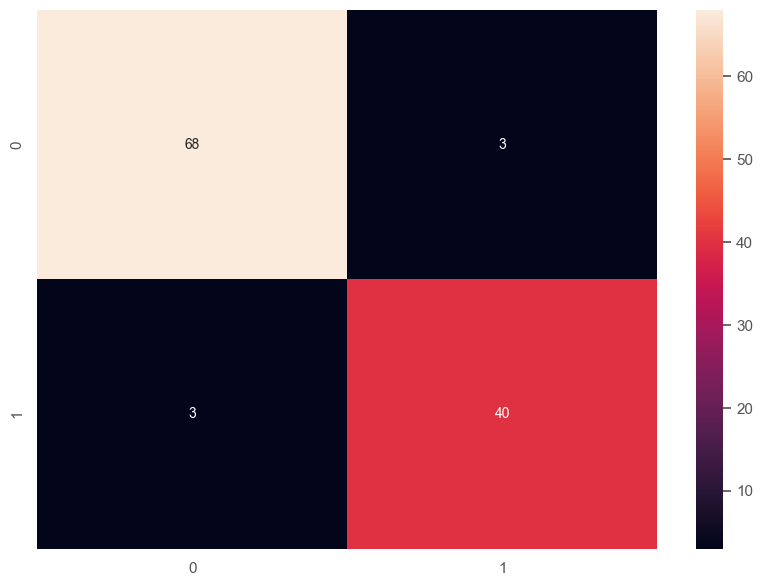

In [17]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(classification_report(y_test, y_pred))
plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
print(accuracy_score(y_test, y_pred))

In [19]:
data_2 = pd.read_csv("C:/DEPI/Amit/Src/ML/Session_7/code/Social_Network_Ads.csv")
data_2.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [20]:
data_2.shape

(400, 5)

In [21]:
x = data_2.iloc[:, [2, 3]].values
y = data_2.iloc[:, 4].values

In [22]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [23]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [25]:
from sklearn.svm import SVC
sv_classifier = SVC(kernel='linear', random_state=42)
sv_classifier.fit(x_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


              precision    recall  f1-score   support

           0       0.85      0.96      0.90        52
           1       0.90      0.68      0.78        28

    accuracy                           0.86        80
   macro avg       0.88      0.82      0.84        80
weighted avg       0.87      0.86      0.86        80

0.8625


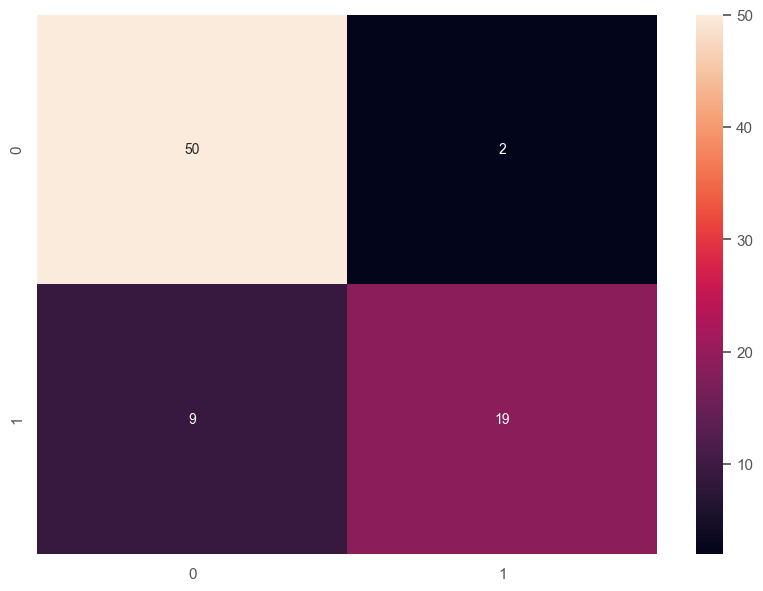

In [26]:
y_pred = sv_classifier.predict(x_test)
print(classification_report(y_test, y_pred))
plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
print(accuracy_score(y_test, y_pred))

In [27]:
from sklearn.model_selection import GridSearchCV
parameters = {
                'C': [0.1, 1, 10, 100], 
                'gamma': [1, 0.1, 0.01, 0.001], 
                'kernel': ['rbf']
             }


In [31]:
grid = GridSearchCV(SVC(), parameters, refit=True, verbose=3, scoring='accuracy', cv=5, n_jobs=-1)
grid.fit(x_train, y_train)
print(grid.best_estimator_)


Fitting 5 folds for each of 16 candidates, totalling 80 fits
SVC(C=0.1, gamma=1)


In [42]:
pd.DataFrame(grid.cv_results_).sort_values(by=['mean_test_score', 'std_test_score'], ascending=False).head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,param_kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.008793,0.002415,0.009851,0.003912,0.1,1.0,rbf,"{'C': 0.1, 'gamma': 1, 'kernel': 'rbf'}",0.937500,0.953125,0.906250,0.875000,0.859375,0.906250,0.035630,1
4,0.004948,0.000970,0.002551,0.000187,1.0,1.0,rbf,"{'C': 1, 'gamma': 1, 'kernel': 'rbf'}",0.937500,0.953125,0.906250,0.859375,0.875000,0.906250,0.035630,1
13,0.013167,0.014205,0.005910,0.002450,100.0,0.1,rbf,"{'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}",0.937500,0.953125,0.890625,0.859375,0.890625,0.906250,0.034233,1
12,0.021423,0.015042,0.009199,0.008996,100.0,1.0,rbf,"{'C': 100, 'gamma': 1, 'kernel': 'rbf'}",0.921875,0.953125,0.875000,0.875000,0.859375,0.896875,0.035078,4
8,0.005413,0.001862,0.003399,0.001562,10.0,1.0,rbf,"{'C': 10, 'gamma': 1, 'kernel': 'rbf'}",0.921875,0.937500,0.890625,0.875000,0.843750,0.893750,0.033366,5


              precision    recall  f1-score   support

           0       0.96      0.92      0.94        52
           1       0.87      0.93      0.90        28

    accuracy                           0.93        80
   macro avg       0.91      0.93      0.92        80
weighted avg       0.93      0.93      0.93        80

0.925


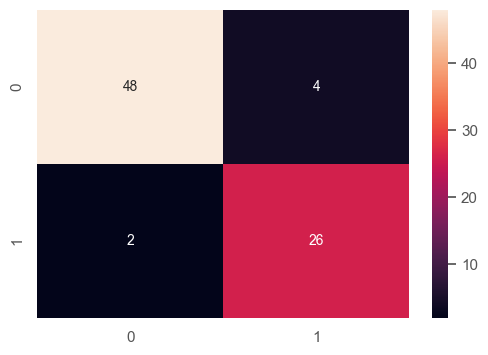

In [34]:
grid_predictions = grid.predict(x_test)
print(classification_report(y_test, grid_predictions))
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, grid_predictions), annot=True, fmt='d')
print(accuracy_score(y_test, grid_predictions))

In [43]:
gid_mean_scors = grid.cv_results_['mean_test_score']
print("Mean test scores for each parameter combination:")
for mean_score, params in zip(gid_mean_scors, grid.cv_results_['params']):
    print(f"Parameters: {params}, Mean Test Score: {mean_score:.4f}")


Mean test scores for each parameter combination:
Parameters: {'C': 0.1, 'gamma': 1, 'kernel': 'rbf'}, Mean Test Score: 0.9062
Parameters: {'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}, Mean Test Score: 0.8344
Parameters: {'C': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}, Mean Test Score: 0.6406
Parameters: {'C': 0.1, 'gamma': 0.001, 'kernel': 'rbf'}, Mean Test Score: 0.6406
Parameters: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}, Mean Test Score: 0.9062
Parameters: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}, Mean Test Score: 0.8938
Parameters: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}, Mean Test Score: 0.8219
Parameters: {'C': 1, 'gamma': 0.001, 'kernel': 'rbf'}, Mean Test Score: 0.6406
Parameters: {'C': 10, 'gamma': 1, 'kernel': 'rbf'}, Mean Test Score: 0.8938
Parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}, Mean Test Score: 0.8938
Parameters: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}, Mean Test Score: 0.8313
Parameters: {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}, Mean Test Score: 0.8094
Parameters: 

Text(0, 0.5, 'cross validation score')

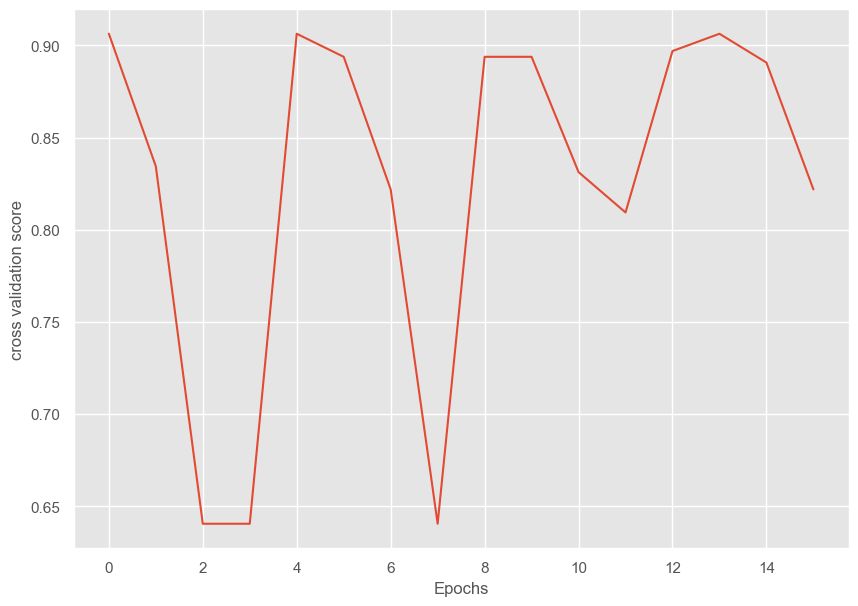

In [46]:
plt.figure(figsize=(10, 7))
plt.plot(gid_mean_scors)
plt.xlabel('Epochs')
plt.ylabel('cross validation score')
